# 04 — Feature Engineering
**Goal:** Build the final feature tables for ALL cohorts using the same pipeline.
Save to data/features/ as parquet files.

**Cohort definition:** Customers whose `Closed_Date` falls within 4 weeks (28 days)
after their `Prospect_Renewal_Date`, with `Prospect_Outcome` in {Won, Churned}.
Label: `Churned` → 1, `Won` → 0.

| Cohort | File | Use |
|--------|------|-----|
| 2024 cohort (4-week window) | train_2024.parquet | Training |
| 2025 cohort (4-week window) | test_2025.parquet  | Testing |
| 2025 cohort (no labels)     | predict_2025.parquet | Live scoring |


In [2]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
# emails excluded (temporal leakage -- arrives after renewal decision)
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print("  emails:        EXCLUDED (temporal leakage)")
print(f"  renewal_calls: {rc.shape}")

from src.features.builder import build_cohort_features, get_feature_columns, build_labels
import pyarrow
FEATURES.mkdir(parents=True, exist_ok=True)


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        EXCLUDED (temporal leakage)
  renewal_calls: (186534, 41)


## Build Training Dataset (2024 cohort, 4-week post-renewal window)


In [3]:

train_df = build_cohort_features(bills, cc, rc, renewal_year=2024, include_labels=True)
feature_cols = get_feature_columns(train_df)

print(f"Training features: {len(feature_cols)}")
print(f"Training rows: {len(train_df):,}")
print(f"Churn rate: {train_df['churn_label'].mean()*100:.2f}%")
print(f"scale_pos_weight: {(train_df['churn_label']==0).sum() / (train_df['churn_label']==1).sum():.1f}")


[2024] Base (4-week post-renewal window): 6,686 customers
[2024] Coverage — cc:536 rc:4,999
[2024] Final: (6686, 68) OK
[2024] Churn rate: 13.98%
Training features: 60
Training rows: 6,686
Churn rate: 13.98%
scale_pos_weight: 6.2


## Build Test Dataset (2025 cohort, 4-week post-renewal window)


In [4]:

test_df = build_cohort_features(bills, cc, rc, renewal_year=2025, include_labels=True)
print(f"Test rows: {len(test_df):,}")
decided = test_df['churn_label'].notna()
print(f"Customers with labels: {decided.sum():,} ({decided.sum()/len(test_df)*100:.1f}%)")
print(f"Churn rate: {test_df.loc[decided,'churn_label'].mean()*100:.2f}%")


[2025] Base (4-week post-renewal window): 6,219 customers
[2025] Coverage — cc:1,903 rc:5,843
[2025] Final: (6219, 68) OK
[2025] Churn rate: 17.90%
Test rows: 6,219
Customers with labels: 6,219 (100.0%)
Churn rate: 17.90%


## Feature Distribution: Train vs Test (distribution shift check)

In [5]:

# Check if the feature distributions are similar between train and test
# If very different, the model may not generalise well
shift_results = []
for col in feature_cols[:20]:  # check top 20 numeric features
    if col in train_df.columns and col in test_df.columns:
        tr = train_df[col].dropna()
        te = test_df[col].dropna()
        ks_stat, ks_p = stats.ks_2samp(tr, te)
        shift_results.append({
            'feature': col,
            'train_mean': round(tr.mean(), 4),
            'test_mean':  round(te.mean(), 4),
            'ks_stat': round(ks_stat, 4),
            'ks_p': round(ks_p, 4),
            'shifted': ks_p < 0.01
        })

shift_df = pd.DataFrame(shift_results).sort_values('ks_stat', ascending=False)
print("Features with potential distribution shift (p < 0.01):")
print(shift_df[shift_df['shifted']].to_string(index=False))
print(f"\nTotal shifted features: {shift_df['shifted'].sum()} / {len(shift_df)}")


Features with potential distribution shift (p < 0.01):
                 feature  train_mean  test_mean  ks_stat   ks_p  shifted
     Last_Total_Net_Paid    746.6256   854.7034   0.1242 0.0000     True
          Connection_Qty      0.0000     0.7213   0.1108 0.0000     True
           band_upgraded      0.1478     0.0605   0.0873 0.0000     True
Renewal_Score_At_Release     25.3694    25.4431   0.0417 0.0000     True
    Sustainability_Score      8.4939     8.5482   0.0399 0.0001     True
                band_enc      3.9984     4.1957   0.0358 0.0005     True
       low_release_score      0.2066     0.2365   0.0300 0.0059     True
      Auto_Renewal_Score      8.4487     8.4200   0.0287 0.0097     True

Total shifted features: 8 / 20


## Null Check on Final Tables

In [6]:

for name, df in [('TRAIN', train_df), ('TEST', test_df)]:
    nulls = df[feature_cols].isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"{name} — columns with nulls after fillna:")
        print(nulls)
    else:
        print(f"{name} — no nulls in feature columns ✓")


TRAIN — no nulls in feature columns ✓
TEST — no nulls in feature columns ✓


## Correlation Matrix of Final Features

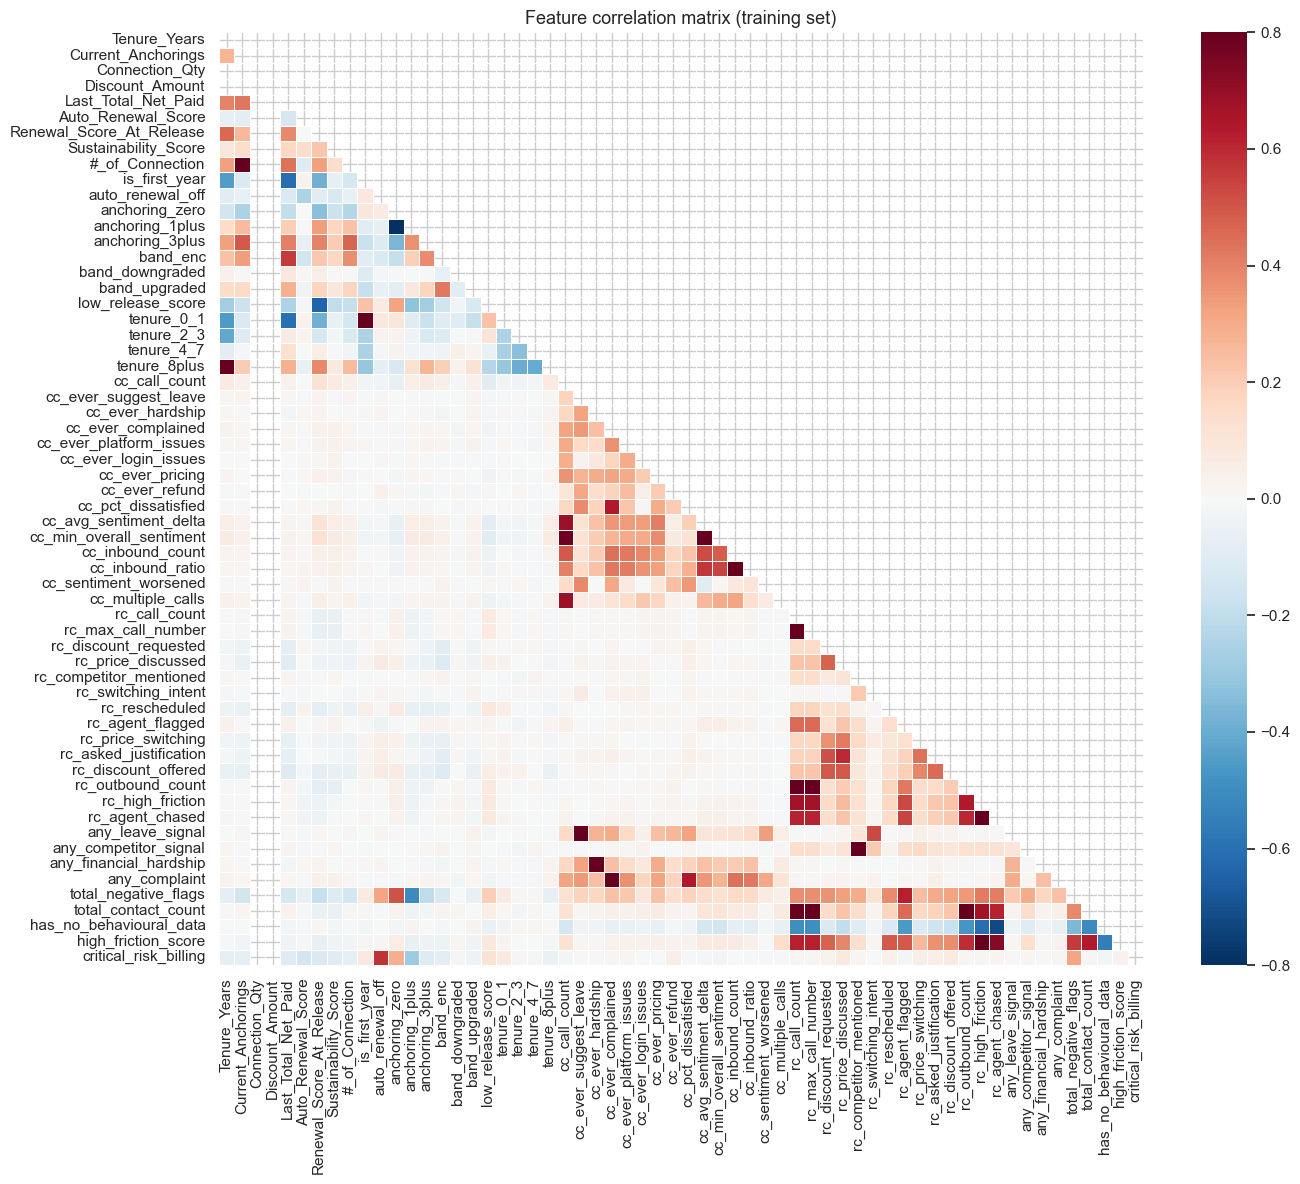

Highly correlated feature pairs (|corr| > 0.7):
  Tenure_Years vs tenure_8plus: 0.846
  Current_Anchorings vs #_of_Connection: 0.933
  is_first_year vs tenure_0_1: 0.984
  anchoring_zero vs anchoring_1plus: -1.000
  cc_call_count vs cc_min_overall_sentiment: 0.785
  cc_ever_suggest_leave vs any_leave_signal: 0.866
  cc_ever_hardship vs any_financial_hardship: 1.000
  cc_ever_complained vs any_complaint: 1.000
  cc_avg_sentiment_delta vs cc_min_overall_sentiment: 0.913
  cc_inbound_count vs cc_inbound_ratio: 0.881
  rc_call_count vs rc_max_call_number: 1.000
  rc_call_count vs rc_outbound_count: 0.981
  rc_call_count vs total_contact_count: 0.994
  rc_max_call_number vs rc_outbound_count: 0.981
  rc_max_call_number vs total_contact_count: 0.994
  rc_competitor_mentioned vs any_competitor_signal: 1.000
  rc_outbound_count vs total_contact_count: 0.975
  rc_high_friction vs rc_agent_chased: 0.820
  rc_high_friction vs high_friction_score: 0.872
  rc_agent_chased vs has_no_behavioural_data

In [7]:

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = train_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-0.8, vmax=0.8, ax=ax, linewidths=0.5,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature correlation matrix (training set)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / 'feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Highly correlated feature pairs (|corr| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i,j]
        if abs(v) > 0.7:
            print(f"  {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {v:.3f}")


## Save All Feature Tables

In [8]:

def save_parquet(df, path):
    df_save = df.copy()
    # fix dtypes
    for col in df_save.select_dtypes(include='category').columns:
        df_save[col] = df_save[col].astype(str)
    for col in df_save.select_dtypes(include='Int64').columns:
        df_save[col] = df_save[col].fillna(0).astype(int)
    for col in df_save.select_dtypes(include='object').columns:
        df_save[col] = df_save[col].astype(str)
    df_save.to_parquet(path, index=False)
    print(f"Saved: {path.name} — {df_save.shape}")

save_parquet(train_df, FEATURES / 'train_2024.parquet')
save_parquet(test_df,  FEATURES / 'test_2025.parquet')

# save feature list
import json
with open(FEATURES / 'feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"Feature columns saved ({len(feature_cols)} features)")

# print final summary
print()
print("=== FINAL DATASET SUMMARY ===")
print(f"Training set:  {len(train_df):,} rows × {len(feature_cols)} features | churn={train_df['churn_label'].mean()*100:.2f}%")
print(f"Test set:      {len(test_df):,} rows × {len(feature_cols)} features")


Saved: train_2024.parquet — (6686, 70)
Saved: test_2025.parquet — (6219, 70)
Feature columns saved (60 features)

=== FINAL DATASET SUMMARY ===
Training set:  6,686 rows × 60 features | churn=13.98%
Test set:      6,219 rows × 60 features
